# Spots and Faculae

This tutorial shows how to use `spotgp` to:
1. Define starspots with different envelope shapes and plot their lightcurves
2. Use `SpotEvolutionModel` to combine envelope + visibility into a physical model
3. Compute wavelength-dependent contrast for spots and faculae
4. Simulate a lightcurve with both spots and faculae

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from spotgp import (
    LightcurveModel,
    SpotEvolutionModel,
    TrapezoidSymmetricEnvelope,
    TrapezoidAsymmetricEnvelope,
    ExponentialEnvelope,
    VisibilityFunction,
    contrast_factor,
    spot_contrast,
)

np.random.seed(42)

## 1. Basic spot lightcurve

`LightcurveModel` is the simplest way to simulate a spotted star. Specify the stellar rotation period, inclination, spot properties, and it computes the lightcurve automatically.

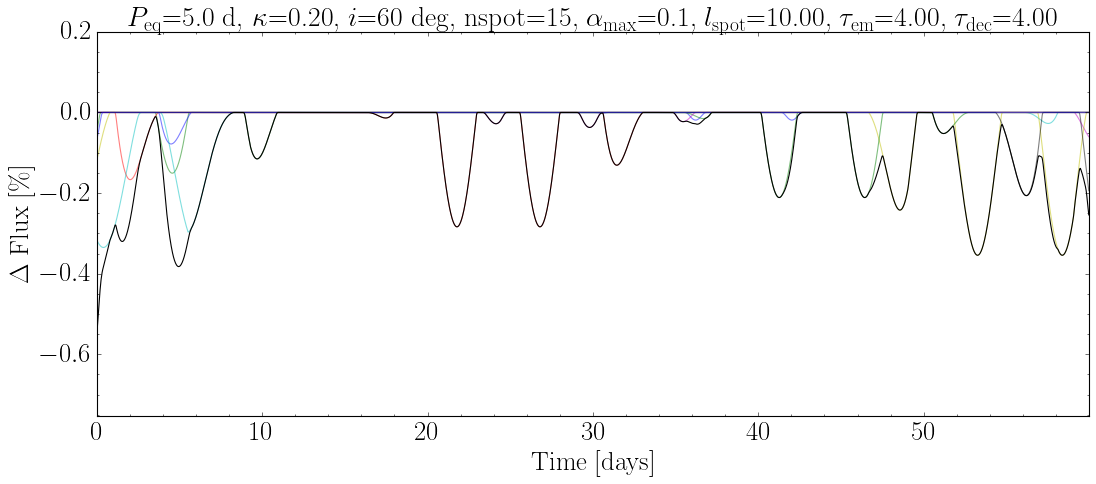

In [2]:
lc = LightcurveModel(
    peq=5.0,            # equatorial rotation period [days]
    kappa=0.2,          # differential rotation shear
    inc=np.pi / 3,      # inclination [rad] (60 deg)
    nspot=15,           # number of spots
    alpha_max=0.06,     # peak spot angular radius [rad]
    fspot=0.0,          # spot contrast (0 = black spot)
    lspot=10.0,         # plateau duration [days]
    tau_spot=4.0,       # symmetric rise/decay timescale [days]
    tsim=60,            # simulation length [days]
    tsamp=0.02,         # cadence [days]
)

fig = lc.plot_lightcurve()
fig

## 2. Spot envelope shapes

The envelope function $\Gamma(t)$ controls how a spot's size evolves over time: emergence, plateau, and decay. `spotgp` provides several built-in shapes.

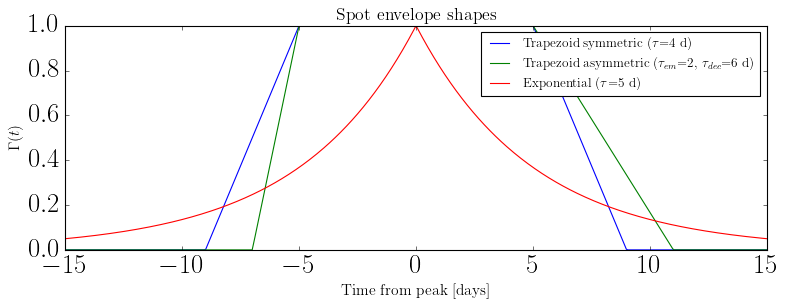

In [3]:
env_sym = TrapezoidSymmetricEnvelope(lspot=10.0, tau_spot=4.0)
env_asym = TrapezoidAsymmetricEnvelope(lspot=10.0, tau_em=2.0, tau_dec=6.0)
env_exp = ExponentialEnvelope(tau_spot=5.0)

t = np.linspace(-15, 15, 500)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, env_sym.Gamma(t), label="Trapezoid symmetric ($\\tau$=4 d)")
ax.plot(t, env_asym.Gamma(t), label="Trapezoid asymmetric ($\\tau_{em}$=2, $\\tau_{dec}$=6 d)")
ax.plot(t, env_exp.Gamma(t), label="Exponential ($\\tau$=5 d)")
ax.set_xlabel("Time from peak [days]", fontsize=14)
ax.set_ylabel("$\\Gamma(t)$", fontsize=14)
ax.legend(fontsize=12)
ax.set_title("Spot envelope shapes", fontsize=16)
plt.tight_layout()

## 3. Building a model with `SpotEvolutionModel`

For more control, define the envelope and visibility separately, then combine them into a `SpotEvolutionModel`. This is the same model used by the GP kernel.

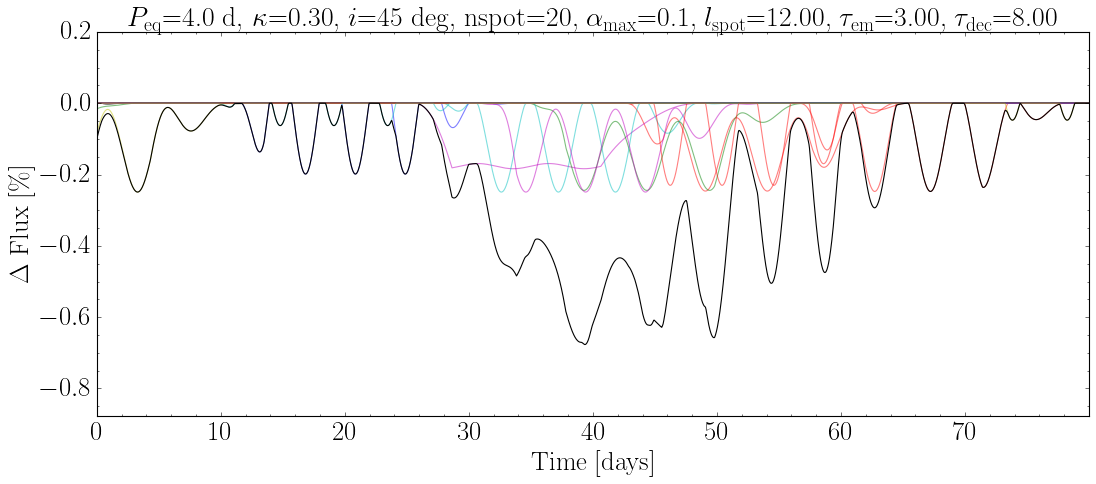

In [4]:
envelope = TrapezoidAsymmetricEnvelope(lspot=12.0, tau_em=3.0, tau_dec=8.0)
visibility = VisibilityFunction(peq=4.0, kappa=0.3, inc=np.pi / 4)

model = SpotEvolutionModel(
    envelope=envelope,
    visibility=visibility,
    nspot_rate=0.5,     # spots per day
    alpha_max=0.05,     # peak angular radius [rad]
    fspot=0.0,          # black spots
)

lc2 = LightcurveModel.from_spot_model(model, nspot=20, tsim=80, tsamp=0.02)
fig = lc2.plot_lightcurve()
fig

## 4. Wavelength-dependent contrast: spots vs. faculae

Spots are cooler than the photosphere ($T_{\rm spot} < T_{\rm phot}$) and cause dimming. Faculae are hotter ($T_{\rm fac} > T_{\rm phot}$) and cause brightening.

The contrast factor $c(\lambda) = 1 - B_\lambda(T) / B_\lambda(T_{\rm phot})$ is:
- **Positive** for spots (flux deficit)
- **Negative** for faculae (flux excess)

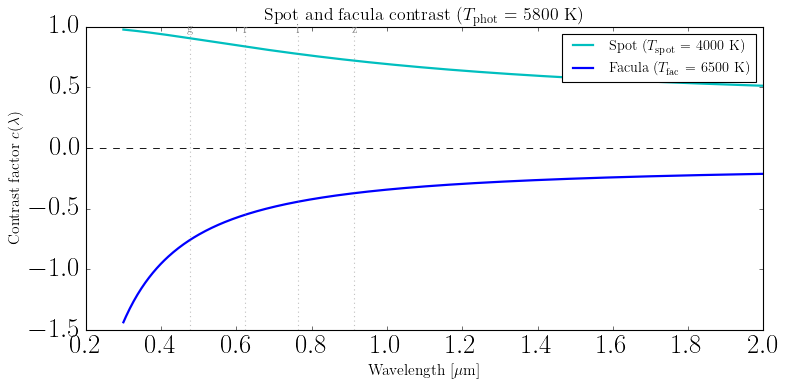

In [5]:
T_phot = 5800  # Sun-like photosphere [K]
T_spot = 4000  # cool spot [K]
T_fac = 6500   # hot facula [K]

lam = np.linspace(3000, 20000, 500)  # wavelength [Angstroms]

c_spot = np.array(contrast_factor(lam, T_spot, T_phot))
c_fac = np.array(contrast_factor(lam, T_fac, T_phot))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lam / 1e4, c_spot, label=f"Spot ($T_{{\\rm spot}}$ = {T_spot} K)", color="C3", lw=2)
ax.plot(lam / 1e4, c_fac, label=f"Facula ($T_{{\\rm fac}}$ = {T_fac} K)", color="C0", lw=2)
ax.axhline(0, color="k", ls="--", lw=0.8)
ax.set_xlabel("Wavelength [$\\mu$m]", fontsize=14)
ax.set_ylabel("Contrast factor $c(\\lambda)$", fontsize=14)
ax.set_title(f"Spot and facula contrast ($T_{{\\rm phot}}$ = {T_phot} K)", fontsize=16)
ax.legend(fontsize=13)

# Mark common photometric bands
for name, wav in [("g", 4770), ("r", 6231), ("i", 7625), ("z", 9134)]:
    ax.axvline(wav / 1e4, color="gray", ls=":", alpha=0.5)
    ax.text(wav / 1e4, ax.get_ylim()[1] * 0.95, name, ha="center", fontsize=11, color="gray")

plt.tight_layout()

## 5. Simulating spots and faculae together

The `fspot` parameter controls the contrast of each active region. In `LightcurveModel`, `fspot` is the spot-to-photosphere flux ratio:
- `fspot = 0`: completely dark (black spot)
- `fspot = 0.5`: spot emits half the photospheric flux
- `fspot > 1`: region is *brighter* than the photosphere (facula)

We can run separate spot and facula populations and combine their lightcurves.

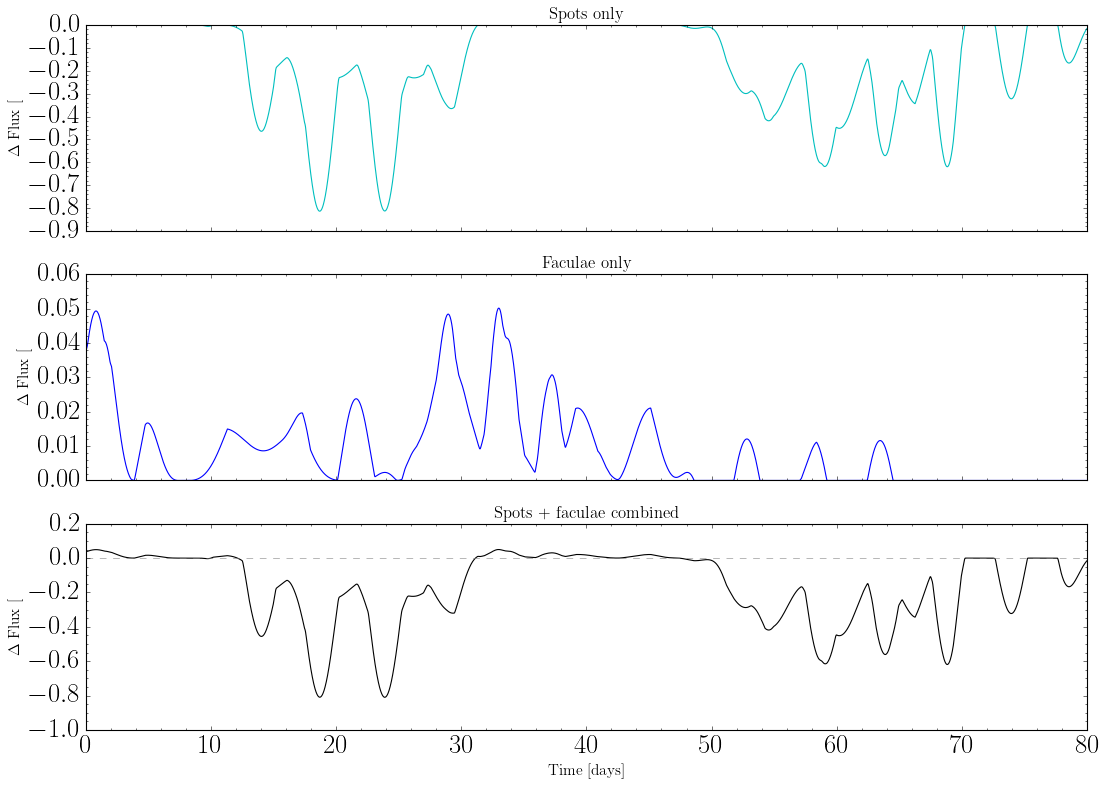

In [6]:
np.random.seed(12)

# Spot population: dark, long-lived
lc_spots = LightcurveModel(
    peq=5.0, kappa=0.2, inc=np.pi / 3,
    nspot=12, alpha_max=0.06, fspot=0.0,
    lspot=12.0, tau_spot=4.0,
    tsim=80, tsamp=0.02,
)

# Facula population: bright, smaller, shorter-lived
np.random.seed(12)
lc_faculae = LightcurveModel(
    peq=5.0, kappa=0.2, inc=np.pi / 3,
    nspot=20, alpha_max=0.04, fspot=1.15,
    lspot=6.0, tau_spot=3.0,
    tsim=80, tsamp=0.02,
)

# Combined flux: each lightcurve is a fractional deviation from 1
flux_spots = lc_spots.flux + lc_spots.dlimb
flux_faculae = lc_faculae.flux + lc_faculae.dlimb
flux_combined = flux_spots + flux_faculae - 1  # subtract double-counted baseline

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(lc_spots.t, (flux_spots - 1) * 100, color="C3")
axes[0].set_ylabel("$\\Delta$ Flux [%]", fontsize=14)
axes[0].set_title("Spots only", fontsize=15)

axes[1].plot(lc_faculae.t, (flux_faculae - 1) * 100, color="C0")
axes[1].set_ylabel("$\\Delta$ Flux [%]", fontsize=14)
axes[1].set_title("Faculae only", fontsize=15)

axes[2].plot(lc_spots.t, (flux_combined - 1) * 100, color="k")
axes[2].set_ylabel("$\\Delta$ Flux [%]", fontsize=14)
axes[2].set_xlabel("Time [days]", fontsize=14)
axes[2].set_title("Spots + faculae combined", fontsize=15)

for ax in axes:
    ax.axhline(0, color="gray", ls="--", lw=0.5)
    ax.minorticks_on()

plt.tight_layout()

## 6. Effect of spot parameters

Comparing how different physical parameters change the lightcurve morphology.

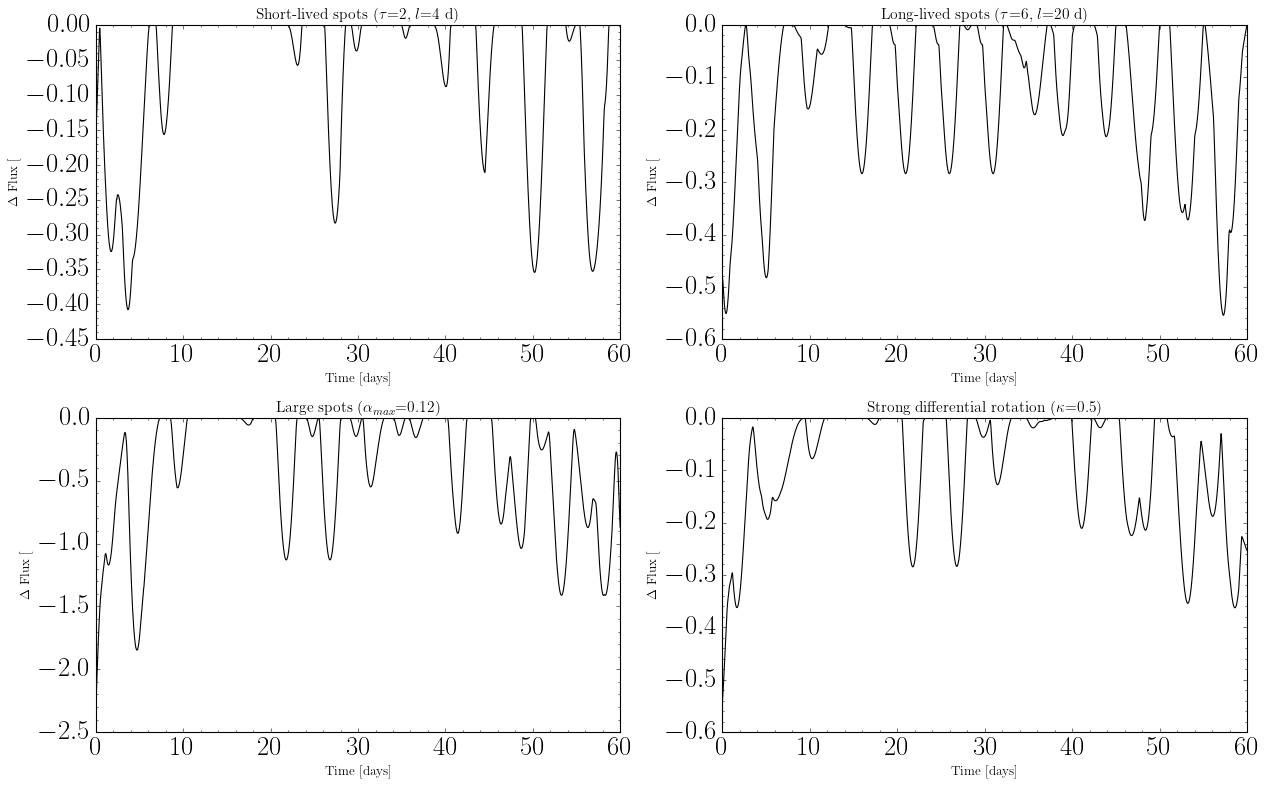

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

configs = [
    {"title": "Short-lived spots ($\\tau$=2, $l$=4 d)", "tau_spot": 2.0, "lspot": 4.0, "alpha_max": 0.06, "kappa": 0.0},
    {"title": "Long-lived spots ($\\tau$=6, $l$=20 d)", "tau_spot": 6.0, "lspot": 20.0, "alpha_max": 0.06, "kappa": 0.0},
    {"title": "Large spots ($\\alpha_{max}$=0.12)", "tau_spot": 4.0, "lspot": 10.0, "alpha_max": 0.12, "kappa": 0.0},
    {"title": "Strong differential rotation ($\\kappa$=0.5)", "tau_spot": 4.0, "lspot": 10.0, "alpha_max": 0.06, "kappa": 0.5},
]

for ax, cfg in zip(axes.flat, configs):
    np.random.seed(42)
    lc_i = LightcurveModel(
        peq=5.0, inc=np.pi / 3, nspot=15, fspot=0.0, tsim=60, tsamp=0.02,
        tau_spot=cfg["tau_spot"], lspot=cfg["lspot"],
        alpha_max=cfg["alpha_max"], kappa=cfg["kappa"],
    )
    flux_i = lc_i.flux + lc_i.dlimb
    ax.plot(lc_i.t, (flux_i - 1) * 100, color="k")
    ax.set_title(cfg["title"], fontsize=14)
    ax.set_xlabel("Time [days]", fontsize=12)
    ax.set_ylabel("$\\Delta$ Flux [%]", fontsize=12)
    ax.minorticks_on()

plt.tight_layout()